<a href="https://colab.research.google.com/github/IreneAbbey/The-Logistics-Auditor/blob/dev/Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Story 1: The Schema Builder**

In [2]:
#Load datasets
orders = pd.read_csv('olist_orders_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

In [3]:
master_ds = orders.merge(reviews, on='order_id', how='inner') \
                  .merge(customers, on='customer_id', how='inner')

In [4]:
#Ensure no duplicate rows were introduced by the joins
print("Duplicate rows:", master_ds.duplicated().sum())

Duplicate rows: 0


# **Story 2: The "Real" Delay Calculator**

In [5]:
#Convert columns to actual datetime objects
master_ds['order_estimated_delivery_date'] = pd.to_datetime(master_ds['order_estimated_delivery_date'])
master_ds['order_delivered_customer_date'] = pd.to_datetime(master_ds['order_delivered_customer_date'])

In [6]:
master_ds['Days_Difference'] = (
    master_ds['order_estimated_delivery_date'] - master_ds['order_delivered_customer_date']
).dt.days

In [7]:
def classify_with_flags(row):
    status = row['order_status']

    if status in ['canceled', 'unavailable']:
        return "Not Delivered"

    if pd.isna(row['order_delivered_customer_date']):
        return "In Progress / Unknown"

    days = row['Days_Difference']

    if days >= 0:
        return "On Time"
    elif days >= -5:
        return "Late"
    else:
        return "Super Late"

master_ds['Delivery_Status'] = master_ds.apply(classify_with_flags, axis=1)

# **Story 3: The Geographic Heatmap**

In [8]:
master_ds['is_late'] = master_ds['Delivery_Status'].isin(['Late', 'Super Late'])

In [9]:
state_analysis = master_ds.groupby('customer_state')['is_late'].mean() * 100

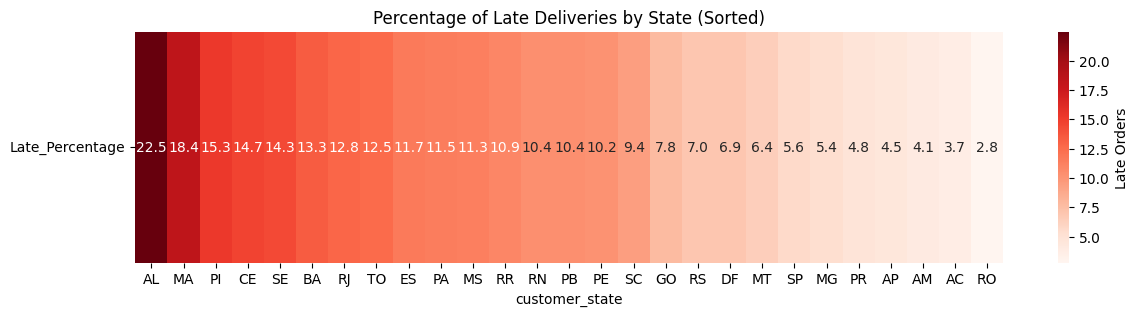

In [18]:
state_analysis = state_analysis.sort_values(ascending=False)

heatmap_data = state_analysis.to_frame(name="Late_Percentage").T

plt.figure(figsize=(14, 3))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    cbar_kws={"label": "Late Orders"}
)

plt.title("Percentage of Late Deliveries by State (Sorted)")
plt.yticks(rotation=0)
plt.show()

In [22]:
near_sp_states = ["SP", "RJ", "MG", "ES"]

master_ds["is_remote"] = master_ds["customer_state"].isin(near_sp_states)

In [24]:
remote_vs_near = (
    master_ds
    .groupby("is_remote")["is_late"]
    .mean() * 100
)

print(remote_vs_near)

is_remote
False    9.162169
True     7.119361
Name: is_late, dtype: float64


# **Story 4: The Sentiment Correlation**

In [40]:
sentiment_summary = master_ds.groupby('Delivery_Status')['review_score'].mean()
print(sentiment_summary)

Delivery_Status
In Progress / Unknown    1.826426
Late                     3.460658
Not Delivered            1.672471
On Time                  4.293718
Super Late               1.787901
Name: review_score, dtype: float64


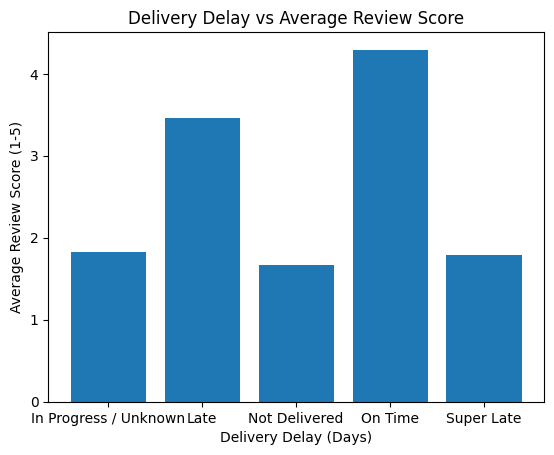

In [32]:
plt.figure()
plt.bar(sentiment_summary.index, sentiment_summary.values)

plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Average Review Score (1-5)")
plt.title("Delivery Delay vs Average Review Score")

plt.show()

In [39]:
On_time = sentiment_summary['On Time']
Late = sentiment_summary['Late']

comparison = f"Average On Time Orders Review Score: {On_time: .2f} vs Average Late Orders Review Score:{Late: .2f} "

print(comparison)

Average On Time Orders Review Score:  4.29 vs Average Late Orders Review Score: 3.46 
